<a href="https://colab.research.google.com/github/MuhammadUsmanAslam111/ai_intern_week04/blob/main/cat_and_dog_implementation_of_CNN_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy  as np
from tensorflow import keras
import matplotlib as plt

In [2]:
data=keras.datasets.cifar10

In [3]:
(train_images,train_labels), (test_images,test_labels)=data.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
train_filter = np.where((train_labels == 3) | (train_labels == 5))[0]
test_filter = np.where((test_labels == 3) | (test_labels == 5))[0]


In [5]:
train_images = train_images[train_filter]
train_labels = train_labels[train_filter]
test_images = test_images[test_filter]
test_labels = test_labels[test_filter]

In [7]:
print("Training data shape:",train_images.shape, train_labels.shape)
print("Testing data shape:", test_images.shape, test_labels.shape)

Training data shape: (10000, 32, 32, 3) (10000, 1)
Testing data shape: (2000, 32, 32, 3) (2000, 1)


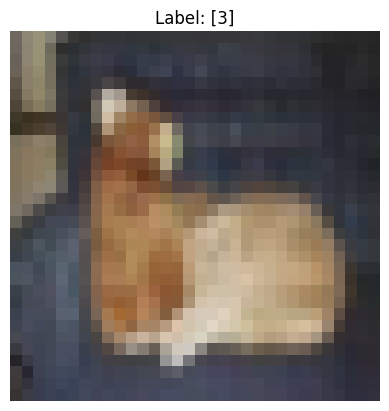

In [8]:
import matplotlib.pyplot as plt
plt.imshow(train_images[1])
plt.title(f"Label: {train_labels[1]}")
plt.axis('off')
plt.show()

In [9]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [10]:
for i, name in enumerate(class_names):
    print(i, "→", name)

0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck


In [11]:
train_images=train_images/255
test_images=test_images/255

In [12]:
model = keras.Sequential([
    keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
   keras.layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    keras.layers.Flatten(),
    keras.layers.Dense(
        64,
        activation='relu'
    ),
    keras.layers.Dense(10, activation='softmax')
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [14]:
model.fit(train_images,train_labels,epochs=3)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5558 - loss: 0.7494
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6693 - loss: 0.6046
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7098 - loss: 0.5574


In [15]:
test_loss , test_acc =model.evaluate(test_images,test_labels)
print("test ACC: ",test_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6804 - loss: 0.5960
test ACC:  0.6890000104904175


In [17]:
prediction=model.predict(test_images)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/tmp/ipykernel_1675/2383366510.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel("Actual: " + class_names[int(test_labels[i])])


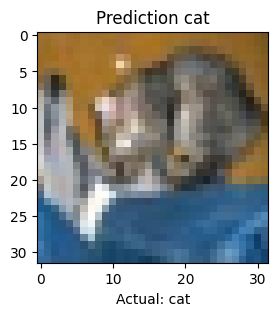

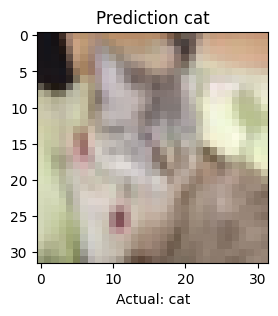

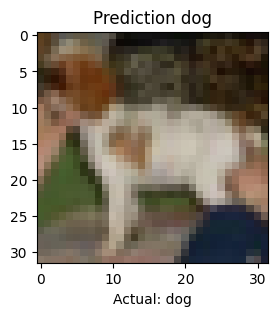

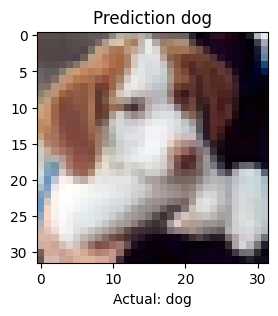

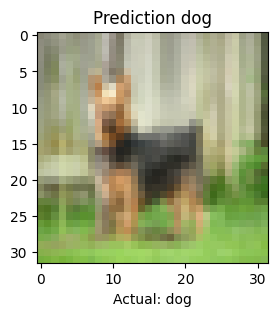

In [18]:
for i in range(5):
    plt.figure(figsize=(3, 3))  #
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    plt.xlabel("Actual: " + class_names[int(test_labels[i])])
    plt.title("Prediction " + class_names[np.argmax(prediction[i])])
    plt.show()

In [19]:
model.save('best_model.h5')

In [20]:
import os
from PIL import Image
import numpy as np

In [21]:
base_dir = "data"  # base folder
folders = ["train/cats", "train/dogs", "test/cats", "test/dogs"]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

In [23]:
for i, img in enumerate(train_images):
    label = train_labels[i]
    folder = "train/cats" if label == 0 else "train/dogs"

    # Convert to uint8
    img_uint8 = (img * 255).astype(np.uint8)
    img_pil = Image.fromarray(img_uint8)

    img_pil.save(os.path.join(base_dir, folder, f"{label}_{i}.png"))

In [24]:
for i, img in enumerate(test_images):
    label = test_labels[i]
    folder = "test/cats" if label == 0 else "test/dogs"

    img_uint8 = (img * 255).astype(np.uint8)
    img_pil = Image.fromarray(img_uint8)

    img_pil.save(os.path.join(base_dir, folder, f"{label}_{i}.png"))

In [25]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=(64, 64),  # or (32,32) for CIFAR-10
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=(64, 64),
    batch_size=32
)

Found 10000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
